### 1. Load the data

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
personal_messy = pd.read_csv("./data/employees_personal_messy.csv")
work_messy = pd.read_csv("./data/employees_work_messy.csv")
perf_messy = pd.read_csv("./data/employees_performance_messy.csv")

In [59]:
personal_messy.head()

,employee_id,name,email,city,country
0,EMP0013,Tina Martin,tina.martin@company.com,berlin,germany
1,EMP0081,YaRa GARCiA,yara.garcia@company.com,berlin,germany
2,EMP0034,OlivIA() MArTiN,olivia.martin@company.com,PARIS,france
3,EMP0006,WENdy GarCIA,wendy.garcia@company.com,rome,italy
4,EMP0188,Jack Thompson,jack.thompson@company.com,london,uk


In [60]:
work_messy.head()

,employee_id,department,hire_date,salary
0,EMP0059,ENGINEERING,2019-06-16,NaN
1,EMP0041,saLes,2014-09-15,"$93,466"
2,EMP0035,MARKETING,2021-01-18,"$58,959"
3,EMP0103,marketing,2013-12-20,"$52,176"
4,EMP0185,FINANCE,2018-06-11,"$82,678"


In [61]:
perf_messy.head()

,employee_id,performance_score,satisfaction
0,EMP0026,1.1,NaN
1,EMP0085,-999.0,1
2,EMP0128,4.4,4
3,EMP0011,-999.0,3
4,EMP0179,3.1,NaN


### 2. Merge the data

In [62]:
merge_messy = (
  personal_messy
  .merge(work_messy, how="outer", on=["employee_id"])
  .merge(perf_messy, how="outer", on=["employee_id"])
)

merge_messy.head()

,employee_id,name,email,city,country,department,hire_date,salary,performance_score,satisfaction
0,EMP0001,CARol. DaVIS,carol.davis@company.com,lisbon,portugal,hr,NaN,"$99,096",4.0,5
1,EMP0002,UMa KiNg,uma.king@company.com,brussels,belgium,sales,2014-09-14,"$53,103",-999.0,1
2,EMP0003,Rachel Taylor,rachel.taylor@company.com,amsterdam,netherlands,sales,2017-07-28,"$57,477",4.6,2
3,EMP0004,Leo White,leo.white@company.com,lisbon,portugal,ENGINEERING,2022-11-22,"$59,187",3.4,3
4,EMP0005,LEO TAYLOr,leo.taylor@company.com,MADRID,spain,sALeS,2020-02-19,"$48,304",4.3,2


### 3. Compute stats

In [63]:
salary = merge_messy["salary"].dropna().map(lambda s: int(str(s).removeprefix("$").replace(",", "")))

print(f"Mean: {salary.mean()}")
print(f"Median: {salary.median()}")
print(f"Std: {salary.std()}")


Mean: 69024.56756756757
Median: 67411.0
Std: 22475.946485609344


### 4. Some vizualizations

<Axes: xlabel='country', ylabel='count'>

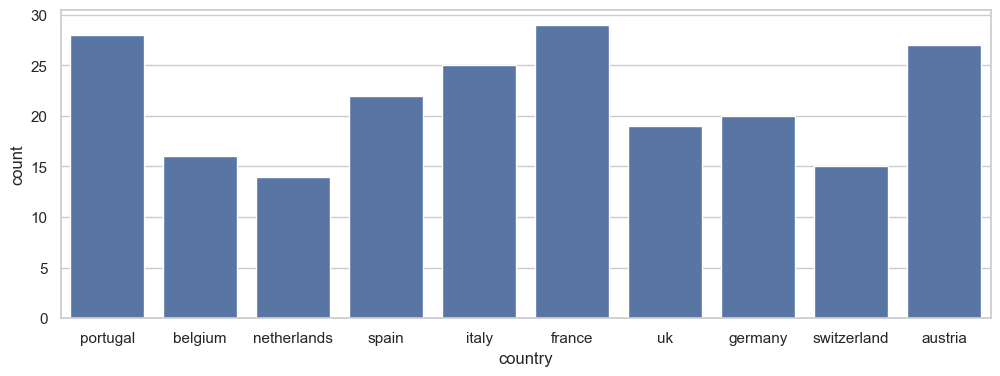

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.countplot(x="country", data=merge_messy, ax=ax)

### 5. Data sampling

In [47]:
sample_1 = merge_messy.sample(frac=.2)

sample_2 = merge_messy.groupby("country", group_keys=False).apply(lambda g: g.sample(frac=.2))
sample_2["country"] = merge_messy.loc[sample_2.index, "country"]

In [48]:
sample_1.head()


,employee_id,name,email,city,country,department,hire_date,salary,performance_score,satisfaction
57,EMP0054,Mona Miller,mona.miller@company.com,london,uk,sales,2013-12-23,NaN,4.7,5
184,EMP0172,Carol White,carol.white@company.com,madrid,spain,OPERATIONS,2015-08-10,"$62,115",1.1,4
78,EMP0074,David Scott,david.scott@company.com,madrid,spain,ENGINEERING,2011-07-19,"$50,526",-999.0,2
187,EMP0175,Steve Young,steve.young@company.com,london,uk,operations,2012-01-25,"$46,136",2.3,2
119,EMP0113,Olivia Williams,olivia.williams@company.com,vienna,austria,SALES,2015-03-22,"$90,796",4.6,5


In [49]:
sample_2.head()


,employee_id,name,email,city,department,hire_date,salary,performance_score,satisfaction,country
155,EMP0145,Zoe King,zoe.king@company.com,vienna,sales,2011-04-06,NaN,2.8,-1,austria
132,EMP0124,Mona King,mona.king@company.com,vienna,engineering,2012-03-25,"$46,284",3.2,4,austria
195,EMP0182,David King,david.king@company.com,vienna,hr,NaN,"$51,226",-999.0,2,austria
62,EMP0059,Tina Brown,tina.brown@company.com,vienna,ENGINEERING,2019-06-16,NaN,-999.0,2,austria
81,EMP0077,Irene Taylor,irene.taylor@company.com,vienna,hr,NaN,"$71,788",2.6,3,austria


#### 5.1 Sample 1 stats

In [53]:
salary_1 = sample_1["salary"].dropna().map(lambda s: int(str(s).removeprefix("$").replace(",", "")))

print(f"Mean: {salary_1.mean()}")
print(f"Median: {salary_1.median()}")
print(f"Std: {salary_1.std()}")


Mean: 66792.30303030302
Median: 62115.0
Std: 23160.830559757633


<Axes: xlabel='country', ylabel='count'>

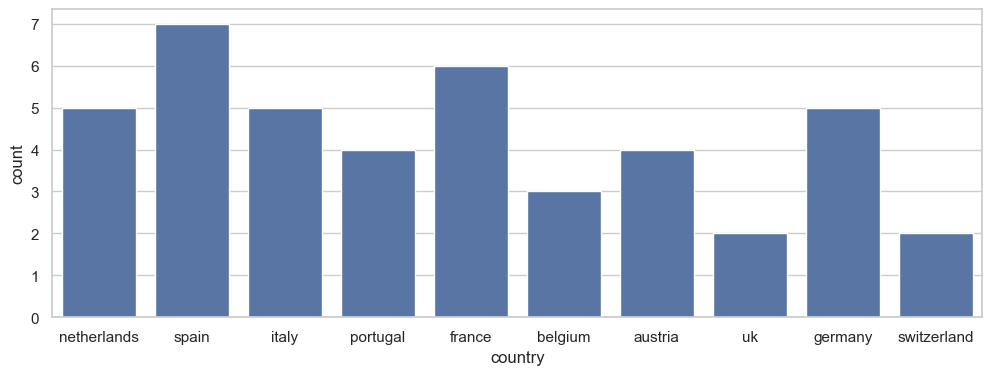

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.set_theme(style="whitegrid")

sns.countplot(x="country", data=sample_1, ax=ax)

#### 5.2 Sample 2 stats

In [54]:
salary_2 = sample_2["salary"].dropna().map(lambda s: int(str(s).removeprefix("$").replace(",", "")))

print(f"Mean: {salary_2.mean()}")
print(f"Median: {salary_2.median()}")
print(f"Std: {salary_2.std()}")


Mean: 67479.93548387097
Median: 60986.0
Std: 22078.46013491503


<Axes: xlabel='country', ylabel='count'>

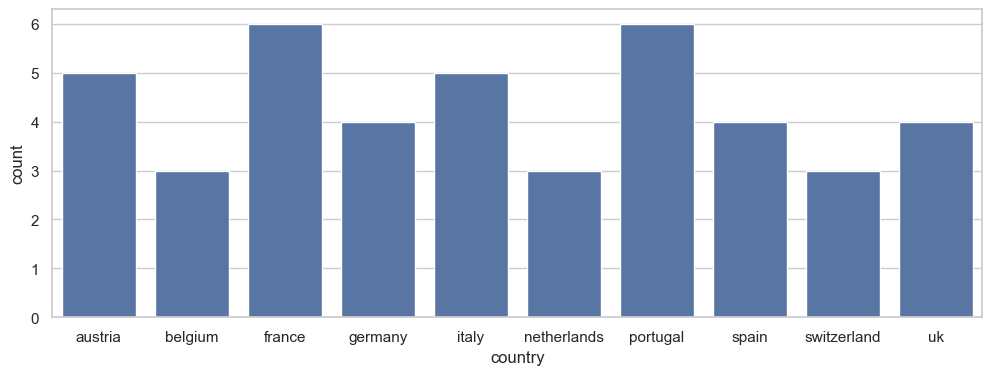

In [50]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.set_theme(style="whitegrid")

sns.countplot(x="country", data=sample_2, ax=ax)